In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
from scipy.signal import find_peaks
from scipy import ndimage


In [2]:
def enhance_edges(
    gray: np.ndarray,
    method: str = "laplacian",
    strength: float = 1.0,
    blur_ksize: int = 3,
) -> np.ndarray:
    """
    Estrae i bordi dall'immagine e li somma ad essa per evidenziarli.
    Da chiamare su gray_eq, prima del bilateral filter.

    Flusso:
        gray  →  estrazione bordi  →  gray + strength * bordi  →  clip [0,255]

    Restituisce
    -----------
    enhanced : np.ndarray (dtype=uint8)
        Immagine grayscale con bordi accentuati.

    Parametri
    ---------
    method : str  [default: "laplacian"]
        Operatore usato per estrarre i bordi.

        "laplacian"  → derivata seconda isotropica. Rileva bordi in tutte
                       le direzioni contemporaneamente. Buon compromesso
                       per ghiere con denti regolari.

        "sobel"      → derivata prima (gradiente). Più selettivo del
                       Laplaciano, meno sensibile al rumore puntuale.
                       Preferibile se l'immagine ha molto rumore.

        "unsharp"    → unsharp masking (gray - gaussian_blur). Tecnica
                       classica di sharpening fotografico. Rinforza i
                       bordi in modo più naturale e meno aggressivo.
                       Buona scelta come primo tentativo.

    strength : float  [default: 1.0]
        Peso con cui i bordi estratti vengono sommati all'immagine.
        - 0.5  → rinforzo leggero, quasi impercettibile
        - 1.0  → rinforzo bilanciato (default consigliato)
        - 2.0+ → bordi molto marcati, può saturare zone già luminose
        ↑ Aumenta se i bordi dei denti sono ancora poco definiti dopo
          il preprocessing.
        ↓ Riduci se compaiono aloni bianchi attorno ai bordi.

    blur_ksize : int  [default: 3]  — deve essere dispari
        Dimensione del kernel Gaussiano usato internamente.
        - Per "laplacian" e "sobel": sfuma l'immagine prima di derivare,
          riducendo l'amplificazione del rumore.
        - Per "unsharp": dimensione del blur da sottrarre (blur grande =
          sharpening su frequenze più basse = bordi più spessi).
        ↑ Aumenta se il metodo amplifica troppo il rumore di fondo.
        ↓ Riduci (minimo 3) se i denti sono piccoli e i dettagli fini
          vengono persi dal pre-blur.
    """
    if blur_ksize % 2 == 0:
        blur_ksize += 1

    blurred = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

    if method == "laplacian":
        edges = cv2.Laplacian(blurred, cv2.CV_64F)
        edges = np.abs(edges)

    elif method == "sobel":
        sx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=blur_ksize)
        sy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=blur_ksize)
        edges = np.sqrt(sx**2 + sy**2)

    elif method == "unsharp":
        edges = gray.astype(np.float64) - blurred.astype(np.float64)

    else:
        raise ValueError(f"method deve essere 'laplacian', 'sobel' o 'unsharp'. Ricevuto: '{method}'")

    # Normalizza i bordi in [0, 255] prima di sommarli
    edges_norm = edges / (edges.max() + 1e-6) * 255.0

    enhanced = gray.astype(np.float64) + strength * edges_norm
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

    return enhanced



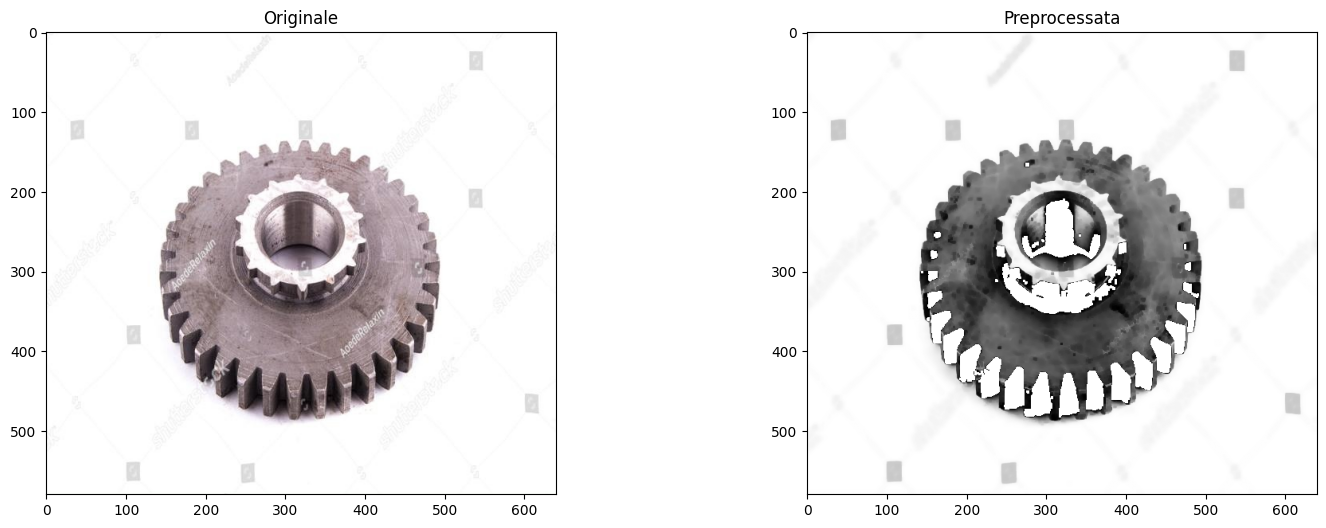

In [8]:


# 1. Lettura e conversione in scala di grigi
img = cv2.imread('./data/train/train_4.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(
    clipLimit=2.0, 
    tileGridSize=(4, 4)
    )

gray_equalized = clahe.apply(gray)

filtered = cv2.bilateralFilter(
    gray, 
    d=9, 
    sigmaColor=15, 
    sigmaSpace=15
    )

blurred = ndimage.minimum_filter(filtered, size=3)

blurred[blurred < 90] = 255



# Display the results
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title('Originale')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title('Preprocessata')
plt.imshow(blurred, cmap='gray')


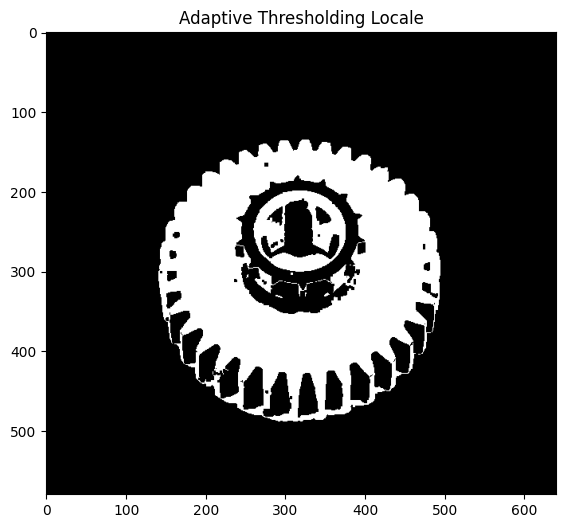

In [9]:
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

if binary[1, 1] == 255:
    binary = cv2.bitwise_not(binary)

# show results
plt.figure(figsize=(12, 6))
plt.title('Adaptive Thresholding Locale')
plt.imshow(binary, cmap='gray')
plt.show()

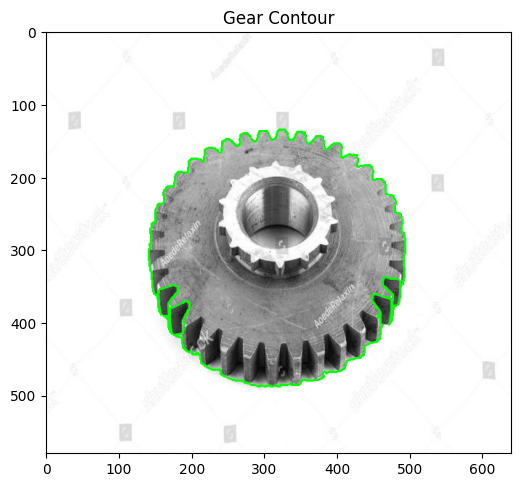

In [10]:
contours, hierarchy = cv2.findContours(
    binary, # binarized and filled image of the gear      
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_TC89_KCOS
)

gear_contour = max(contours, key=cv2.contourArea)

# show the contour
debug = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)  
cv2.drawContours(debug, [gear_contour], -1, (0, 255, 0), 2)  # green contour
plt.figure(figsize=(6, 6))
plt.title('Gear Contour')
plt.imshow(debug)
plt.show()

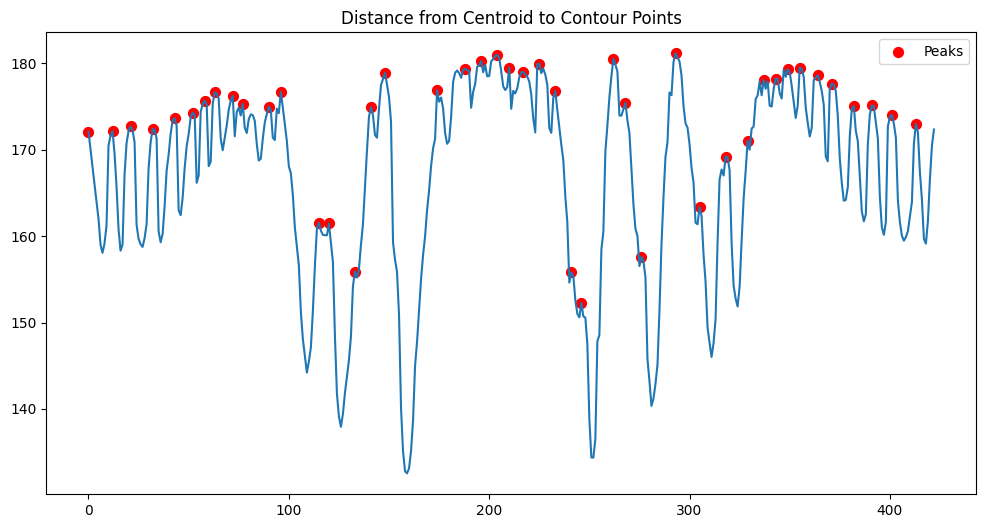

In [259]:
M  = cv2.moments(gear_contour)
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])

# Compute all distances from centroid to every contour point
dists = np.array([np.linalg.norm(p[0] - [cx, cy]) for p in gear_contour])
peaks = find_peaks(dists, distance=5)  # distance=10 to avoid close peaks

# add the first peak corrisponding to the first point of the contour if it's not already included

first_peak = peaks[0][0]
last_peak = peaks[0][-1]

if first_peak in range(1, 5) or last_peak in range(len(gear_contour) - 5, len(gear_contour) - 1):
    pass # the first peak is already included in the first or last points
else:
    peaks = (np.insert(peaks[0], 0, 0),)  # add 0 at the beginning of the peaks
    


# clear peaks removing the ones that are included bewteen two higher peaks
peak_smoothing = 1.2
final_peaks = []
for i in range(len(peaks[0])):
    if i == 0 or i == len(peaks[0]) - 1:
        final_peaks.append(peaks[0][i])
    else:
        prev_peak = peaks[0][i - 1]
        next_peak = peaks[0][i + 1]
        if dists[peaks[0][i]] * peak_smoothing < dists[prev_peak]  and dists[peaks[0][i]] * peak_smoothing < dists[next_peak]:
            continue  # skip this peak
        else:
            final_peaks.append(peaks[0][i])

# plot the distances with peaks
plt.figure(figsize=(12, 6))
plt.title('Distance from Centroid to Contour Points')
plt.plot(dists)
plt.scatter(final_peaks, dists[final_peaks], color='red', s=50, label='Peaks')
plt.legend()
plt.show()




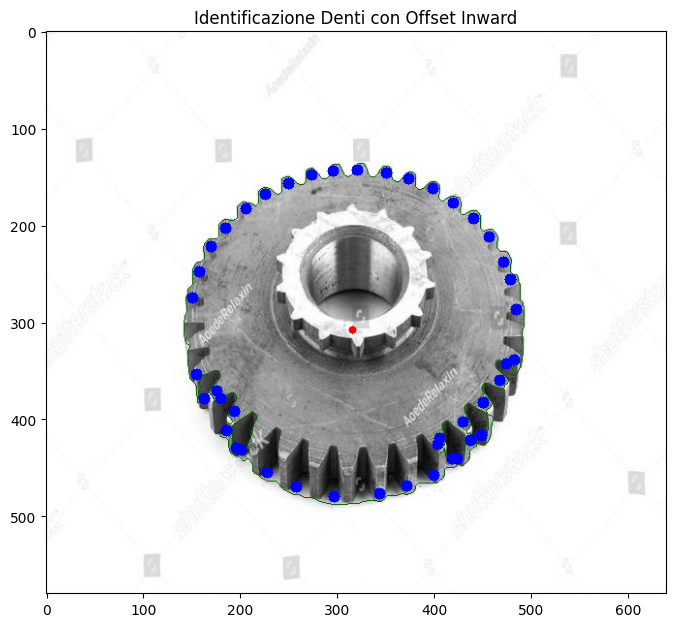

In [260]:
# Array per salvare le coordinate (x, y) dei punti finali sui denti
teeth_points = []

# Quanti pixel vogliamo spostarci dalla punta estrema verso l'interno del dente?
# Regola questo valore in base alla risoluzione della tua immagine e alla dimensione dei denti
offset_inside = 8

for peak_idx in final_peaks:
    # 1. Recupera le coordinate (x, y) della punta esatta dal contorno
    # Ricorda che i contorni di cv2 hanno shape (N, 1, 2)
    tip_x, tip_y = gear_contour[peak_idx][0]
    
    # 2. Calcola il vettore che punta dalla punta del dente verso il baricentro
    dir_x = cx - tip_x
    dir_y = cy - tip_y
    
    # 3. Normalizza il vettore (rendi la sua lunghezza uguale a 1)
    length = np.hypot(dir_x, dir_y) # np.hypot è più rapido per la norma euclidea 2D
    
    if length > 0:
        dir_x_norm = dir_x / length
        dir_y_norm = dir_y / length
        
        # 4. Calcola le nuove coordinate traslate verso l'interno
        final_x = int(tip_x + (dir_x_norm * offset_inside))
        final_y = int(tip_y + (dir_y_norm * offset_inside))
        
        teeth_points.append((final_x, final_y))


# --- VISUALIZZAZIONE FINALE ---
# Usiamo l'immagine a colori per vedere bene i punti
result_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) 

# Disegniamo il contorno in verde scuro
cv2.drawContours(result_img, [gear_contour], -1, (0, 100, 0), 1)

# Disegniamo il baricentro in blu
cv2.circle(result_img, (cx, cy), 4, (255, 0, 0), -1)

# Disegniamo i punti definitivi dei denti in rosso
for pt in teeth_points:
    cv2.circle(result_img, pt, 6, (0, 0, 255), -1)

plt.figure(figsize=(8, 8))
plt.title('Identificazione Denti con Offset Inward')
plt.imshow(result_img)
plt.show()